# 🔬 Comparación: log(Y) vs log(Y)+filtro vs log(Y)+Polinomial
California Housing — Regresión Lineal


  0. Normal
  n = 20,640  |  RMSE = 1.2942  |  R² = 0.5267


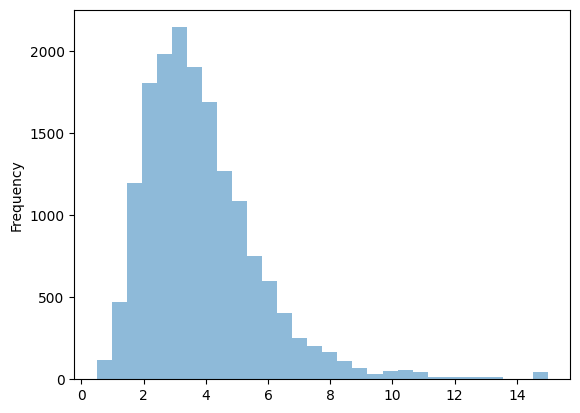

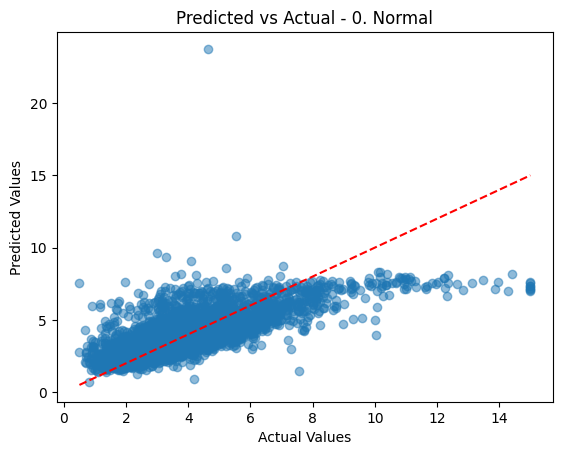

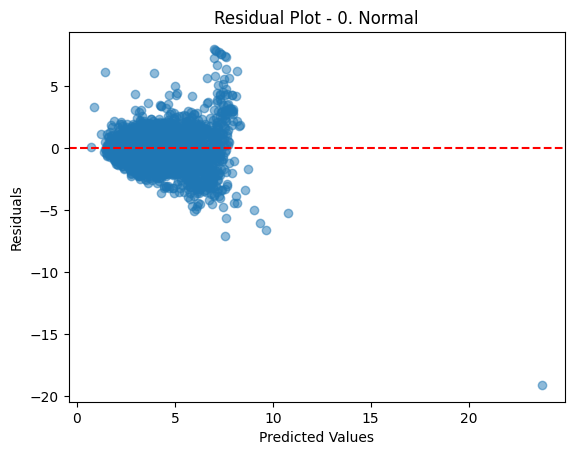


  1. log(Y)
  n = 20,640  |  RMSE = 2.9451  |  R² = -1.4507


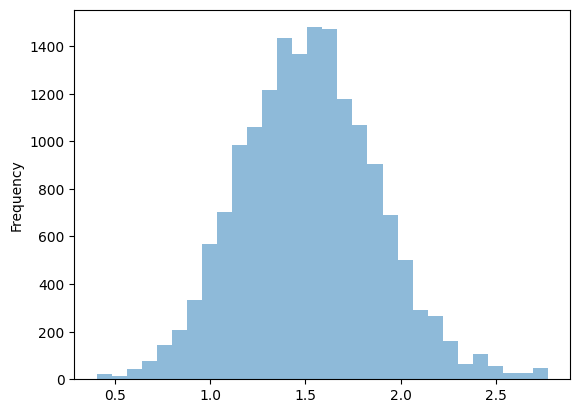

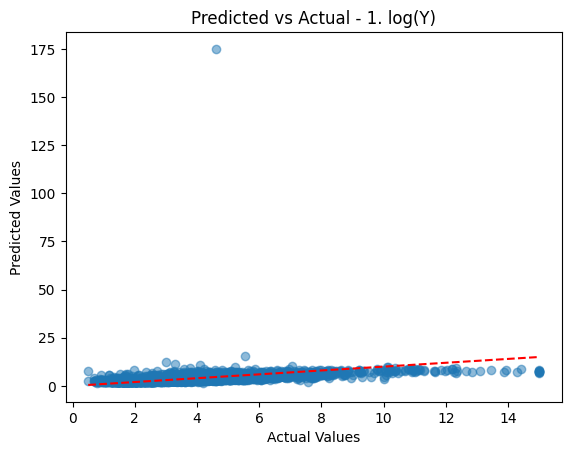

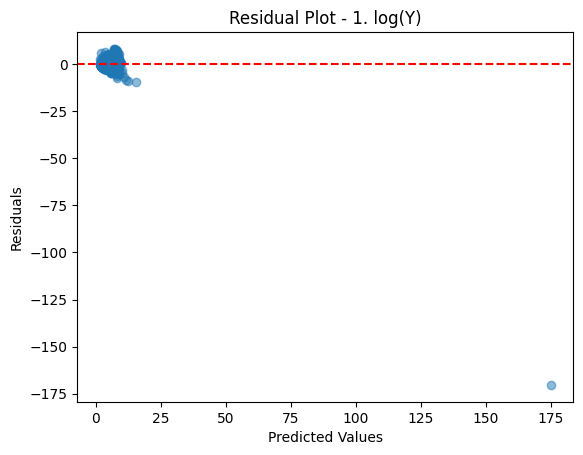


  2. log(Y) + filtro < 15.0
  n = 20,589  |  RMSE = 2.4414  |  R² = -0.7835


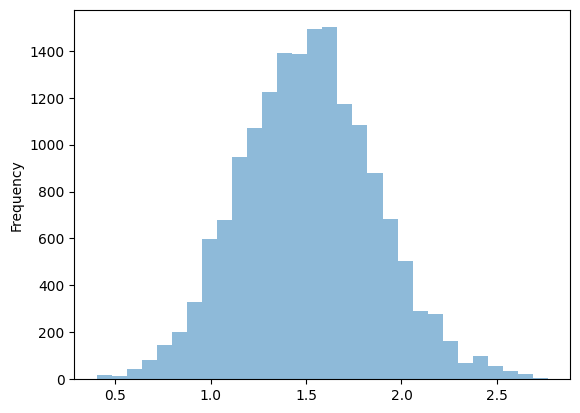

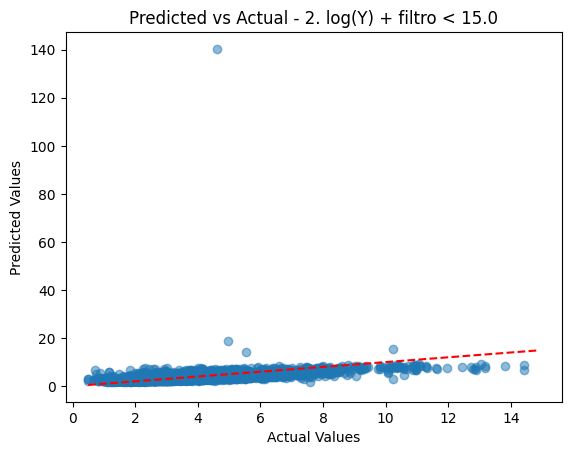

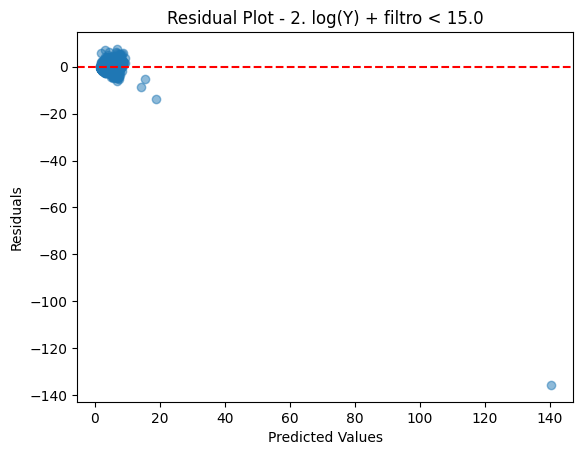


  3. log(Y) + Polinomial²
  n = 20,640  |  RMSE = 1.1424  |  R² = 0.6313


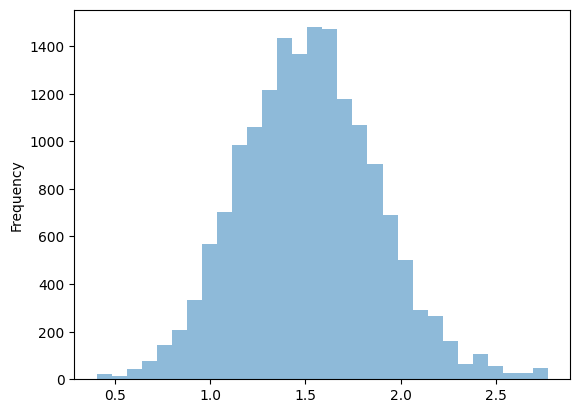

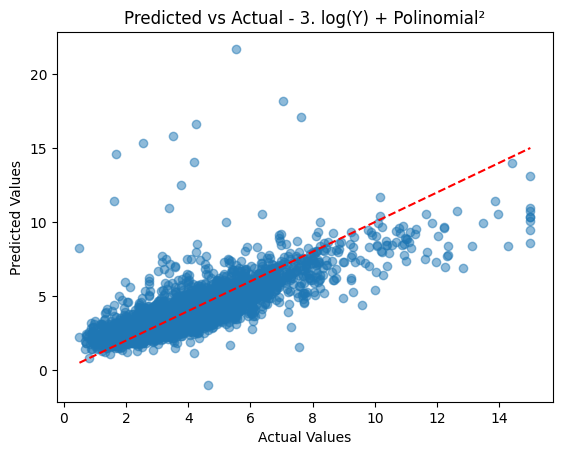

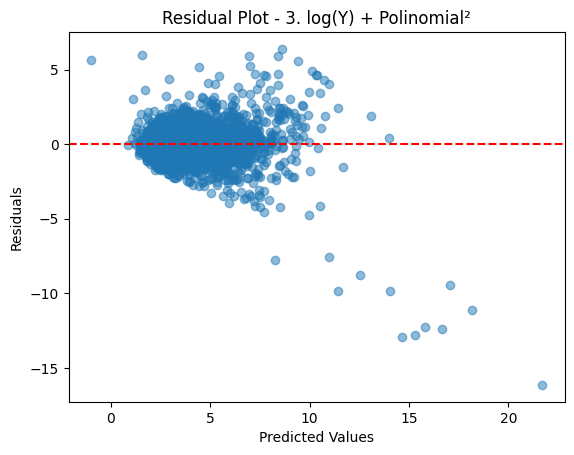


  4. Polinomial²
  n = 20,640  |  RMSE = 1.3453  |  R² = 0.4887


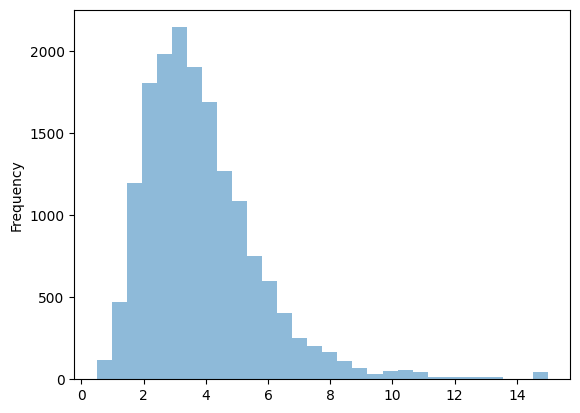

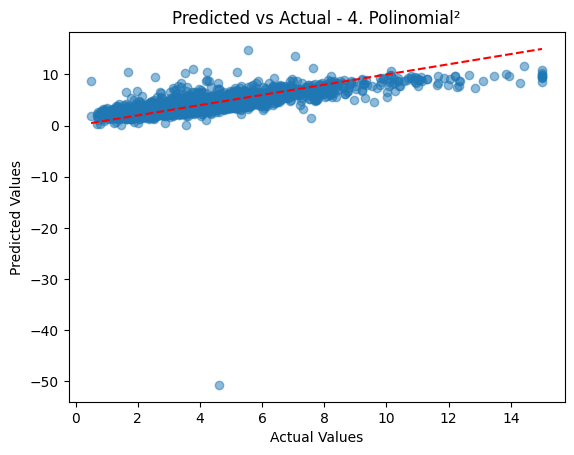

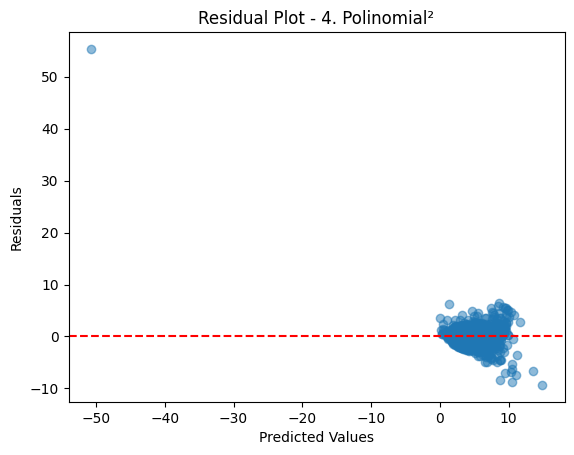

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# ── Datos
housing = fetch_california_housing(as_frame=True).frame.copy()
FEATURES = ['MedHouseVal', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude']
TARGET   = 'MedInc'

def run_experiment(df, label, poly=False):
    X = df[FEATURES]
    y = df[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)
    X_te = scaler.transform(X_test)

    if poly:
        poly_transformer = PolynomialFeatures(degree=2, include_bias=False)
        X_tr = poly_transformer.fit_transform(X_tr)
        X_te = poly_transformer.transform(X_te)

    if label in ('1. log(Y)', '2. log(Y) + filtro < 15.0','3. log(Y) + Polinomial²'):
        y_log_train = np.log1p(y_train)
    else:
        y_log_train = y_train

    model = LinearRegression()
    model.fit(X_tr, y_log_train)
    if label in ('1. log(Y)', '2. log(Y) + filtro < 15.0','3. log(Y) + Polinomial²'):
        y_pred = np.expm1(model.predict(X_te))
    else:
        y_pred = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    res  = y_test.values - y_pred

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"  n = {len(df):,}  |  RMSE = {rmse:.4f}  |  R² = {r2:.4f}")
    print(f"{'='*45}")

    y_log_train.plot.hist(bins=30, alpha=0.5, label='Train')
    plt.show()

    #predicted vs actual
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Predicted vs Actual - {label}')
    plt.show()

    #resudual plot
    plt.scatter(y_pred, res, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(f'Residual Plot - {label}')
    plt.show()

    return y_pred, y_test.values, res, label, r2

# ── 3 experimentos
r0 = run_experiment(housing,                              '0. Normal',                  poly=False)
r1 = run_experiment(housing,                              '1. log(Y)',                  poly=False)
r2 = run_experiment(housing[housing[TARGET] < 15.0].copy(),'2. log(Y) + filtro < 15.0',  poly=False)
r3 = run_experiment(housing,                              '3. log(Y) + Polinomial²',   poly=True)
r4 = run_experiment(housing,                              '4. Polinomial²',         poly=True)